<a href="https://colab.research.google.com/github/vbagkar33-create/CSL701-CE01_Machine-Learning-Lab/blob/main/ML_EXP01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAME : Vinay Janardan Bagkar
ROLL NO. : CE01
BATCH : 1st**


**Aim:** To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

# Objectives
* Understand SLR
* Load/preprocess dataset
* Perform EDA
* Compute OLS coefficients
* Evaluate with SSE, MSE, R²
* Visualize regression and residual plots

# Software Requirements
* Python 3.x
* Jupyter/Colab/VS Code
* Libraries: pandas, numpy, matplotlib, seaborn

# Theory
Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:

$$\hat{y} = w_0 + w_1 x_1$$

In matrix form, including the bias/intercept term $X_0 = 1$:

$$\hat{y} = Xw$$

To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:

$$SSE = \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 = (y - Xw)^T(y - Xw)$$

Solving for w analytically yields the normal equation:

$$\hat{w} = (X^T X)^{-1} X^T y$$


**Note:** The inverse $(X^T X)^{-1}$ exists only if the matrix $X^T X$ is non-singular (i.e., its determinant is non-zero).

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Task 2: Load Auto MPG dataset

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("auto-mpg.csv")

print("Dataset loaded successfully!")
print(df.head())

Saving auto-mpg.csv to auto-mpg.csv
Dataset loaded successfully!
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [7]:
# ============================================================
# Task 3: Inspect and clean data
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Remove rows having missing horsepower or mpg
df = df.dropna(subset=["horsepower", "mpg"])

# Convert horsepower to numeric
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# Remove any remaining missing values
df = df.dropna(subset=["horsepower", "mpg"])

print("\nDataset after cleaning:")
print(df[["horsepower", "mpg"]].head())

print("\nNumber of rows after cleaning:", len(df))



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Dataset after cleaning:
   horsepower   mpg
0       130.0  18.0
1       165.0  15.0
2       150.0  18.0
3       150.0  16.0
4       140.0  1

In [8]:
# ============================================================
# Task 4: Select Horsepower and MPG
# ============================================================

X_data = df["horsepower"].values
y_data = df["mpg"].values

print("\nHorsepower values:")
print(X_data[:10])

print("\nMPG values:")
print(y_data[:10])



Horsepower values:
[130. 165. 150. 150. 140. 198. 220. 215. 225. 190.]

MPG values:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]


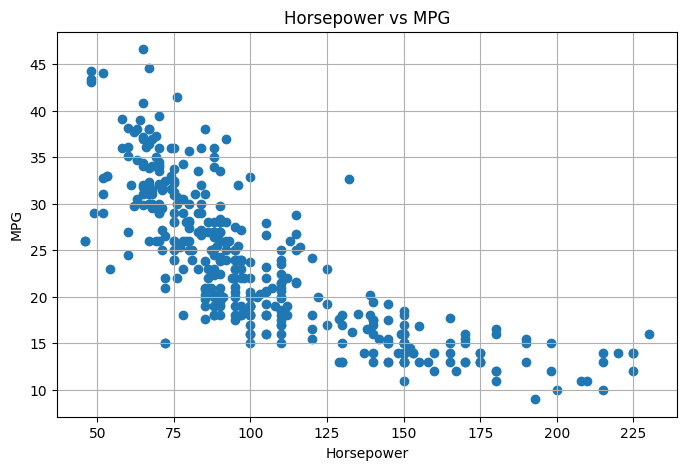

In [11]:
# ============================================================
# Task 5: Plot scatter graph
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(X_data, y_data)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.grid(True)

plt.show()

In [12]:
# ============================================================
# Task 6: Add bias term
# ============================================================

# Convert X into a column vector
X = X_data.reshape(-1, 1)

# Add a column of ones for the intercept/bias term
X_bias = np.column_stack((np.ones(len(X)), X))

print("First 5 rows of X with bias term:")
print(X_bias[:5])

print("\nShape of X matrix:")
print(X_bias.shape)

First 5 rows of X with bias term:
[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]

Shape of X matrix:
(392, 2)


In [13]:
# ============================================================
# Task 7: Compute Correlation
# ============================================================

correlation = np.corrcoef(
    X_data,
    y_data
)[0, 1]

print("\nCorrelation between Horsepower and MPG:")
print(round(correlation, 4))



Correlation between Horsepower and MPG:
-0.7784


In [14]:
# ============================================================
# Task 8: Calculate OLS Weights
# ============================================================

# OLS Normal Equation:
# W = (X^T X)^(-1) X^T Y

XtX = X_bias.T @ X_bias

Xty = X_bias.T @ y_data

# Calculate determinant
determinant = np.linalg.det(XtX)

print("\nDeterminant of X^T X:")
print(determinant)

if abs(determinant) > 1e-10:

    # Calculate inverse
    XtX_inverse = np.linalg.inv(XtX)

    # Calculate weights
    weights = XtX_inverse @ Xty

else:

    print("Matrix is singular.")
    print("Using pseudo-inverse.")

    weights = np.linalg.pinv(X_bias) @ y_data


# Extract intercept and slope
w0 = weights[0]
w1 = weights[1]

print("\nOLS Weights:")
print("Intercept (w0):", w0)
print("Slope (w1):", w1)

print("\nRegression Equation:")

print(
    f"MPG = {w0:.4f} + ({w1:.4f}) × Horsepower"
)




Determinant of X^T X:
227083104.0000001

OLS Weights:
Intercept (w0): 39.93586102117056
Slope (w1): -0.1578447333536543

Regression Equation:
MPG = 39.9359 + (-0.1578) × Horsepower


In [15]:
# ============================================================
# Task 9: Predict Values
# ============================================================

# Predicted MPG
y_pred = X_bias @ weights

print("\nActual vs Predicted MPG:")

result = pd.DataFrame({
    "Actual MPG": y_data,
    "Predicted MPG": y_pred
})

print(result.head(10))



Actual vs Predicted MPG:
   Actual MPG  Predicted MPG
0        18.0      19.416046
1        15.0      13.891480
2        18.0      16.259151
3        16.0      16.259151
4        17.0      17.837598
5        15.0       8.682604
6        14.0       5.210020
7        14.0       5.999243
8        14.0       4.420796
9        15.0       9.945362


In [16]:
# ============================================================
# Task 10: Compute Residuals
# ============================================================

# Residual = Actual - Predicted

residuals = y_data - y_pred

print("\nFirst 10 Residuals:")

print(residuals[:10])



First 10 Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [17]:
# ============================================================
# Task 11: Calculate SSE, MSE and R²
# ============================================================

# Sum of Squared Errors
SSE = np.sum(
    residuals ** 2
)

# Mean Squared Error
MSE = SSE / len(y_data)

# Total Sum of Squares
SST = np.sum(
    (y_data - np.mean(y_data)) ** 2
)

# R-Squared
R2 = 1 - (SSE / SST)

print("\nModel Evaluation")
print("-----------------------------")

print("SSE =", round(SSE, 4))

print("MSE =", round(MSE, 4))

print("R²  =", round(R2, 4))



Model Evaluation
-----------------------------
SSE = 9385.9159
MSE = 23.9437
R²  = 0.6059


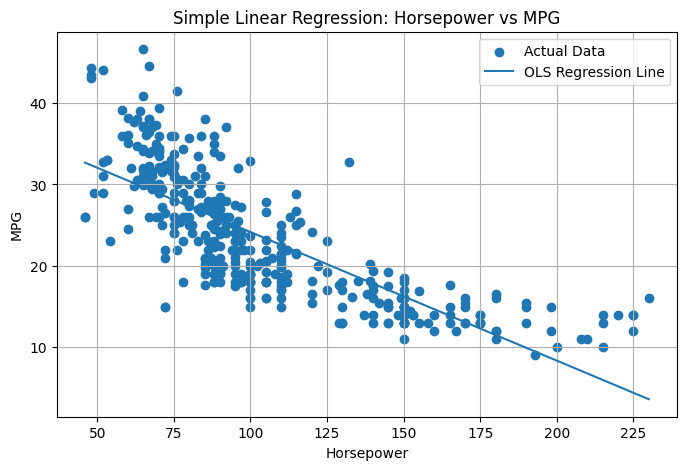

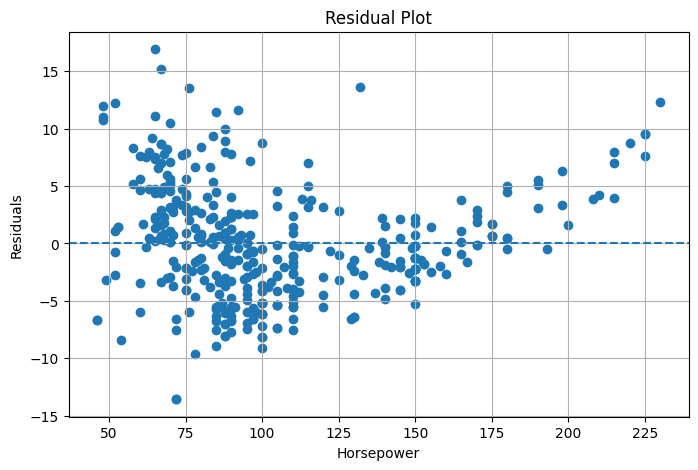

In [19]:
# ============================================================
# Task 12: Plot Regression and Residual Graphs
# ============================================================


# ------------------------------------------------------------
# Regression Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    X_data,
    y_data,
    label="Actual Data"
)

# Sort horsepower values
sort_index = np.argsort(X_data)

# Plot regression line
plt.plot(
    X_data[sort_index],
    y_pred[sort_index],
    label="OLS Regression Line"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.title(
    "Simple Linear Regression: Horsepower vs MPG"
)

plt.legend()

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# Residual Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    X_data,
    residuals
)

# Horizontal zero line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Horsepower")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()


In [20]:
# ============================================================
# Task 13: Interpret Results
# ============================================================

print("\nInterpretation")
print("-----------------------------")

print(
    f"1. Correlation coefficient = {correlation:.4f}"
)

if correlation < 0:
    print(
        "2. Horsepower and MPG have a negative relationship."
    )
else:
    print(
        "2. Horsepower and MPG have a positive relationship."
    )


print(
    f"3. Regression slope = {w1:.4f}"
)


if w1 < 0:
    print(
        "4. As horsepower increases, predicted MPG decreases."
    )
else:
    print(
        "4. As horsepower increases, predicted MPG increases."
    )


print(
    f"5. R² value = {R2:.4f}"
)

print(
    "6. R² represents the proportion of variation in MPG "
    "explained by Horsepower."
)

print(
    "7. The residual plot helps to check whether the "
    "prediction errors are randomly distributed."
)


# ============================================================
# Final Result
# ============================================================

print("\n======================================")
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("======================================")

print("\nFinal Regression Equation:")
print(
    f"MPG = {w0:.4f} + ({w1:.4f}) × Horsepower"
)

print("\nFinal Results:")
print("SSE =", round(SSE, 4))
print("MSE =", round(MSE, 4))
print("R²  =", round(R2, 4))


Interpretation
-----------------------------
1. Correlation coefficient = -0.7784
2. Horsepower and MPG have a negative relationship.
3. Regression slope = -0.1578
4. As horsepower increases, predicted MPG decreases.
5. R² value = 0.6059
6. R² represents the proportion of variation in MPG explained by Horsepower.
7. The residual plot helps to check whether the prediction errors are randomly distributed.

EXPERIMENT COMPLETED SUCCESSFULLY

Final Regression Equation:
MPG = 39.9359 + (-0.1578) × Horsepower

Final Results:
SSE = 9385.9159
MSE = 23.9437
R²  = 0.6059


##Conclusion
The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
